# 2026-10-05 · $L=512$: empirical logits against the variance–profile ansatz

Two $d=\infty$ runs with the same settings and seed: $V=128$, $K=25$, $\beta=0.25$, $\eta_0=3500$, batch 1024, seed 13 (the median learning time of `L_sweep_B1024` at $L=512$).
- `L512_ansatz_study/run_002` (the default, `RUN_ID`): 2500 steps. Scalars at every step (loss, accuracy, the six means, $Q_N,\Gamma_N$, the eight block variances, the profile). Matrices every 5 steps, logit tables at $\mu=L/2,L$. The transition is sharp, $\sim50$ steps around step 1140, so it needs this resolution.
- `run_001`: 8000 steps, log-spaced, 1000 scalar and 200 matrix evaluations. It shows the late-time drift: set `RUN_ID = "run_001"` to run everything on it.

Everything below is recomputed from the saved matrices, on fresh batches.

Four versions of the logit vector at the same trigger queries (paper/scratch/2026-10-05-1107, §4.1 and §5.1):
- **empirical**: the network itself, `logit_table(run.model(step), batch)`;
- **B**: the ansatz mean logits on the *measured* variables of the same sequences, $\bar{\bm h}(\mathfrak S_\mu)$ (the means and the profile of S0, without the variances);
- **B+ξ**: B plus a Gaussian draw of the noise of the variance ansatz, $\widehat{\bm K}(\mathfrak S_\mu)$ (level S0), on the same sequences: tests (C3) and (C5);
- **C**: *sampled* variables at the same $(\mu,\ell)$ plus the noise: the effective model (level (1) of §5.1, what `EffectiveLoss(method="mc")` averages).

Then the effective loss along training, for both methods and all levels S0–S5, against the loss of the network.

**Caveat.** A single network is *quenched* and the formulas are *annealed*. Its $K$ query rows of $\bm Q$ are fixed, so its trigger loss and its noise variances scatter around the annealed values by $O(K^{-1/2})$, up to $\sim0.1$ nats per cluster. A deviation of that size is not a failure of the formulas.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from icl import (RunData, asymptotic_loss, learning_time, EffectiveLoss, LEVELS, at_level, trigger_loss,
                 logit_table, measure_variables, sample_variables, ansatz_logits, sample_logits, noise_variances,
                 cluster_cross_entropy, Evaluator, LossMetric, preprocess_batch)

path = Path('./')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Plot Configs

In [ ]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
        
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code

## 0. The run

In [3]:
BASE, EXPERIMENT, RUN_ID, LONG_RUN_ID = "../data", "L512_ansatz_study", "run_002", "run_001"
run = RunData(EXPERIMENT, RUN_ID, base_dir=BASE)
long_run = RunData(EXPERIMENT, LONG_RUN_ID, base_dir=BASE)
cfg = run.config
V, L, K, beta = cfg.model_args.vocab_size, cfg.model_args.seq_len, cfg.data_args.K, cfg.model_args.beta
L_inf, log_V = asymptotic_loss(V, L, K), math.log(V)
metrics = run.metrics
artifact_steps = run.steps("matrices")
print(f"V={V} L={L} K={K} beta={beta}  log V={log_V:.4f}  L_inf={L_inf:.4f}")
print(f"{len(metrics)} scalar steps, {len(artifact_steps)} matrix snapshots, last step {artifact_steps[-1]}")
print({f: learning_time(metrics['loss'].dropna(), V, L, K, fraction=f) for f in (0.05, 0.2, 0.5, 0.8, 0.95)})
# the transition window, for the zoomed plots
T_START, T_END = (learning_time(metrics['loss'].dropna(), V, L, K, fraction=f) for f in (0.01, 0.99))
TRANSITION = (T_START - 0.5 * (T_END - T_START), T_END + 1.5 * (T_END - T_START))

V=128 L=512 K=25 beta=0.25  log V=4.8520  L_inf=4.2776
2501 scalar steps, 501 matrix snapshots, last step 2500
{0.05: np.float64(1042.0070966453557), 0.2: np.float64(1138.5483815489083), 0.5: np.float64(1150.8030021083564), 0.8: np.float64(1161.9131297934732), 0.95: np.float64(1187.9646470804514)}


## 1. Training curves

Loss and accuracy, then the order parameters as logged during training (the six block means and the diagnostic means $Q_N,\Gamma_N$ that the ansatz sets to 0), then the eight block variances and the profile. `var_M_on` is the spread around the smooth profile, `var_M_on_raw` the spread around $M^{on}$, profile included. The x axis is step + 1 on a log scale.

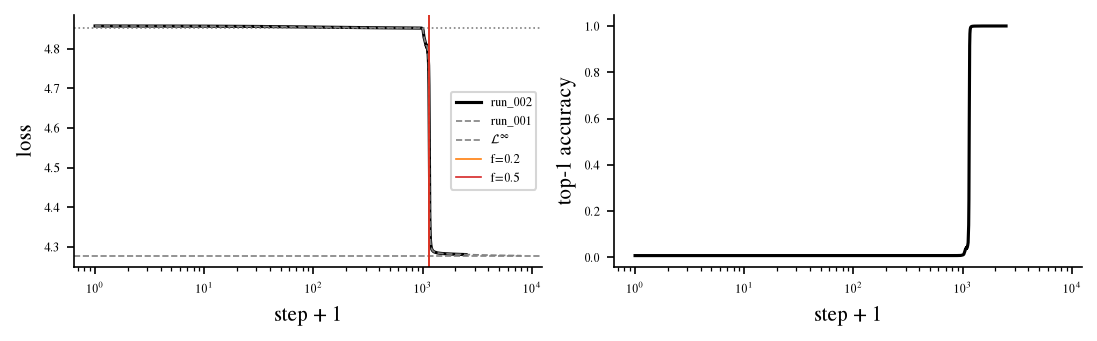

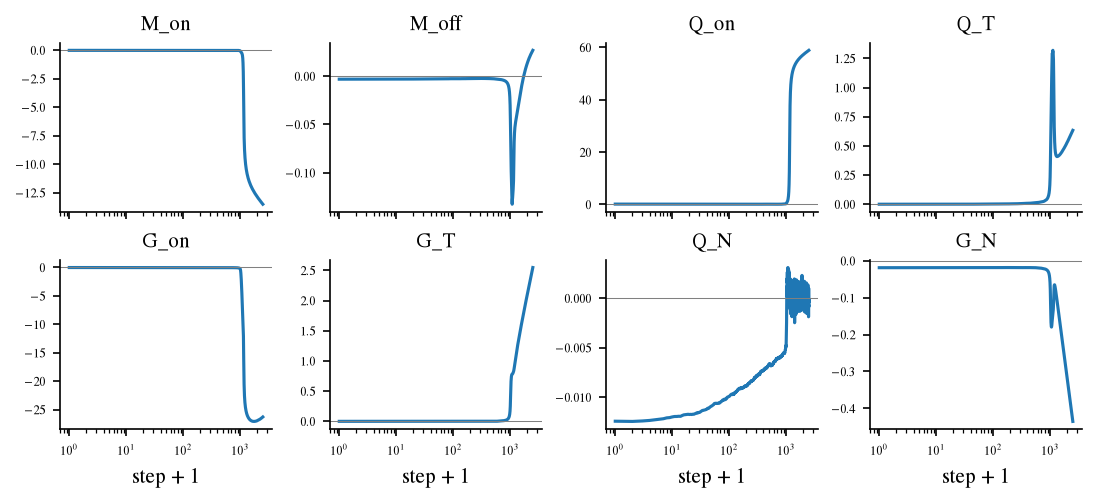

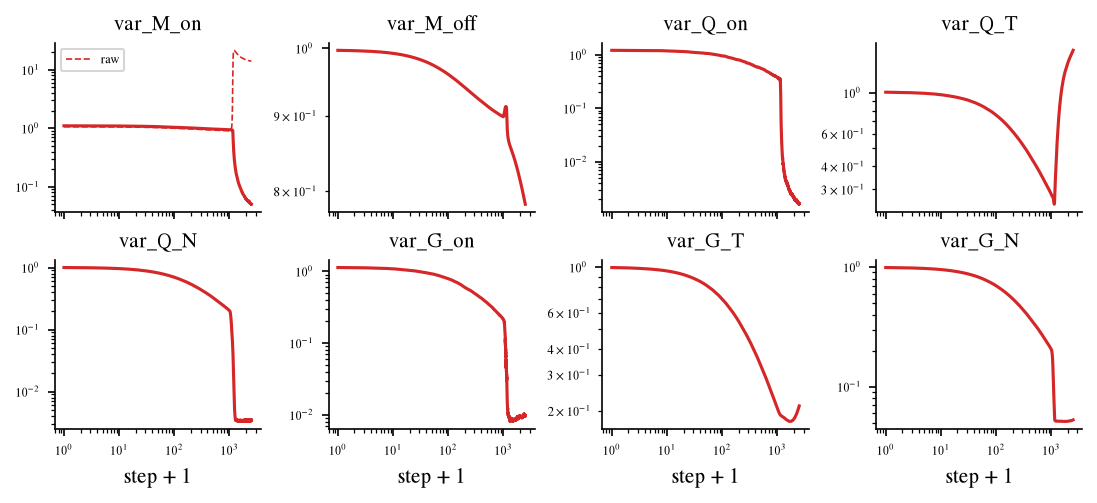

In [4]:
x = metrics.index.to_numpy() + 1
fig, axes = create_fig(1, 2, size='double', h=0.3, sharex=True)
axes[0].plot(x, metrics["loss"], color="k", label=RUN_ID)
if LONG_RUN_ID != RUN_ID:
    long_loss = long_run.metrics["loss"].dropna()
    axes[0].plot(long_loss.index + 1, long_loss, color="0.5", ls="--", lw=0.8, label=LONG_RUN_ID)
axes[0].axhline(log_V, color="gray", ls=":", lw=0.8)
axes[0].axhline(L_inf, color="gray", ls="--", lw=0.8, label=r"$\mathcal{L}^\infty$")
for f, c in ((0.2, "C1"), (0.5, "C3")):
    axes[0].axvline(learning_time(metrics["loss"].dropna(), V, L, K, fraction=f) + 1, color=c, lw=0.8, label=f"f={f}")
axes[0].set(ylabel="loss", xscale="log")
axes[0].legend()
axes[1].plot(x, metrics["top1_accuracy"], color="k")
axes[1].set(ylabel="top-1 accuracy", xscale="log")
for ax in axes:
    ax.set_xlabel("step + 1")
plt.show()

means = ["M_on", "M_off", "Q_on", "Q_T", "G_on", "G_T", "Q_N", "G_N"]
fig, axes = create_fig(2, 4, size='double', h=0.45, sharex=True)
for ax, name in zip(axes.flat, means):
    ax.plot(x, metrics[name], color="C0")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set(title=name, xscale="log")
for ax in axes[-1]:
    ax.set_xlabel("step + 1")
plt.show()

variances = ["var_M_on", "var_M_off", "var_Q_on", "var_Q_T", "var_Q_N", "var_G_on", "var_G_T", "var_G_N"]
fig, axes = create_fig(2, 4, size='double', h=0.45, sharex=True)
for ax, name in zip(axes.flat, variances):
    ax.plot(x, metrics[name], color="C3")
    if name == "var_M_on":
        ax.plot(x, metrics["var_M_on_raw"], color="C3", ls="--", lw=0.8, label="raw")
        ax.legend()
    ax.set(title=name, xscale="log", yscale="log")
for ax in axes[-1]:
    ax.set_xlabel("step + 1")
plt.show()

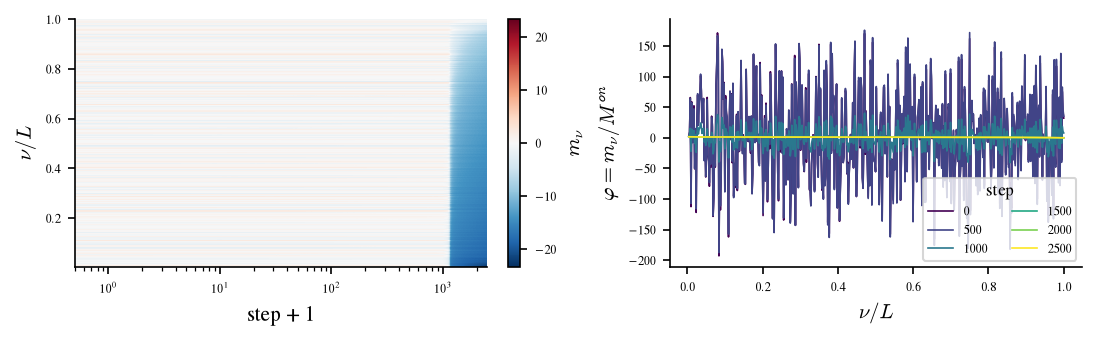

In [5]:
# the previous-token profile m_nu = M[nu, nu-1] over training (MProfile, at every scalar step)
profile_steps = run.steps("profile")
profiles = np.stack([run.profile(s).numpy() for s in profile_steps])        # (steps, L-1), key nu = 2..L
nu_over_L = np.arange(2, L + 1) / L
fig, axes = create_fig(1, 2, size='double', h=0.3, sharex=False)
image = axes[0].pcolormesh(np.array(profile_steps) + 1, nu_over_L, profiles.T, shading="auto", cmap="RdBu_r",
                           vmin=-np.abs(profiles).max(), vmax=np.abs(profiles).max())
fig.colorbar(image, ax=axes[0], label=r"$m_\nu$")
axes[0].set(xscale="log", xlabel="step + 1", ylabel=r"$\nu/L$")
for s, c in zip(np.array(profile_steps)[np.linspace(0, len(profile_steps) - 1, 6).astype(int)], plt.cm.viridis(np.linspace(0, 1, 6))):
    p = profiles[profile_steps.index(s)]
    axes[1].plot(nu_over_L, p / p.mean() if abs(p.mean()) > 1e-8 else p, color=c, lw=0.8, label=f"{s}")
axes[1].set(xlabel=r"$\nu/L$", ylabel=r"$\varphi = m_\nu / M^{on}$")
axes[1].legend(title="step", ncol=2)
plt.show()

## 2. Snapshot steps

Snapshots where the loss has gone a fraction $f$ of the way from $\log V$ to $\mathcal L^\infty$, taken at the nearest saved matrices: the initialisation, $f=0.05,0.2,0.5,0.8$ and the last step.

In [6]:
loss_curve = metrics["loss"].dropna()
progress = (log_V - loss_curve) / (log_V - L_inf)


def nearest_artifact_step(step):
    return min(artifact_steps, key=lambda s: abs(s - step))


SNAPSHOTS = {"init": 0}
for f in (0.05, 0.2, 0.5, 0.8):
    reached = progress.index[progress.to_numpy() >= f]
    if len(reached):
        SNAPSHOTS[f"f={f}"] = nearest_artifact_step(int(reached[0]))
SNAPSHOTS["last"] = artifact_steps[-1]
print(SNAPSHOTS)

{'init': 0, 'f=0.05': 1045, 'f=0.2': 1140, 'f=0.5': 1150, 'f=0.8': 1160, 'last': 2500}


## 3. Logit distributions: empirical against the ansatz

At each snapshot and at $\mu\in\{L/4,L/2,L\}$ the four versions are computed on the same trigger queries of one fresh batch: empirical, B, B+ξ, C (see the top). The order parameters are measured from the matrices of that step, with the profile and the block variances (`run.order_params(step, profile=True, variances=True)`).

In [7]:
NUM_SEQUENCES, BATCH_SEED, NOISE_SEED = 16384, 1, 0
MUS_DIST = [L // 4, L // 2, L]
dist_batch = run.batch(NUM_SEQUENCES, seed=BATCH_SEED, device=DEVICE)
dist_variables = measure_variables(dist_batch, MUS_DIST)        # rows aligned with logit_table on the same batch
SOURCES = {"empirical": "k", "B": "C0", "B+ξ": "C1", "C": "C2"}


def logit_versions(step):
    # the four logit tables (rows, V) in the canonical layout, plus mu, ell, and the measured noise variances
    order_params = run.order_params(step, profile=True, variances=True)
    table = logit_table(run.model(step, device=DEVICE), dist_batch, mus=MUS_DIST, chunk=1024)
    generator = torch.Generator(DEVICE).manual_seed(NOISE_SEED)
    S0 = at_level(order_params, "S0")
    means = {name: value for name, value in S0.items() if not name.startswith("var_")}    # means + profile
    sampled = sample_variables(table["mu"].to(DEVICE), table["ell"].to(DEVICE), V, K, counts="multinomial",
                               generator=generator, device=DEVICE)
    return {"mu": table["mu"], "ell": table["ell"],
            "empirical": table["logits"].double(),
            "B": ansatz_logits(dist_variables, means, beta, L).cpu(),
            "B+ξ": sample_logits(dist_variables, S0, beta, L, generator=generator).cpu(),
            "C": sample_logits(sampled, S0, beta, L, generator=generator).cpu(),
            "noise": {name: value.cpu() for name, value in noise_variances(dist_variables, S0, beta, L).items()}}


versions = {name: logit_versions(step) for name, step in SNAPSHOTS.items()}

### 3a. The target logit, mode by mode

Histograms of $h^{on}$ at $\mu=L$ for $\ell=0,\dots,4$ (columns), one row per snapshot. Empirical as a filled histogram, the three ansatz versions as lines.

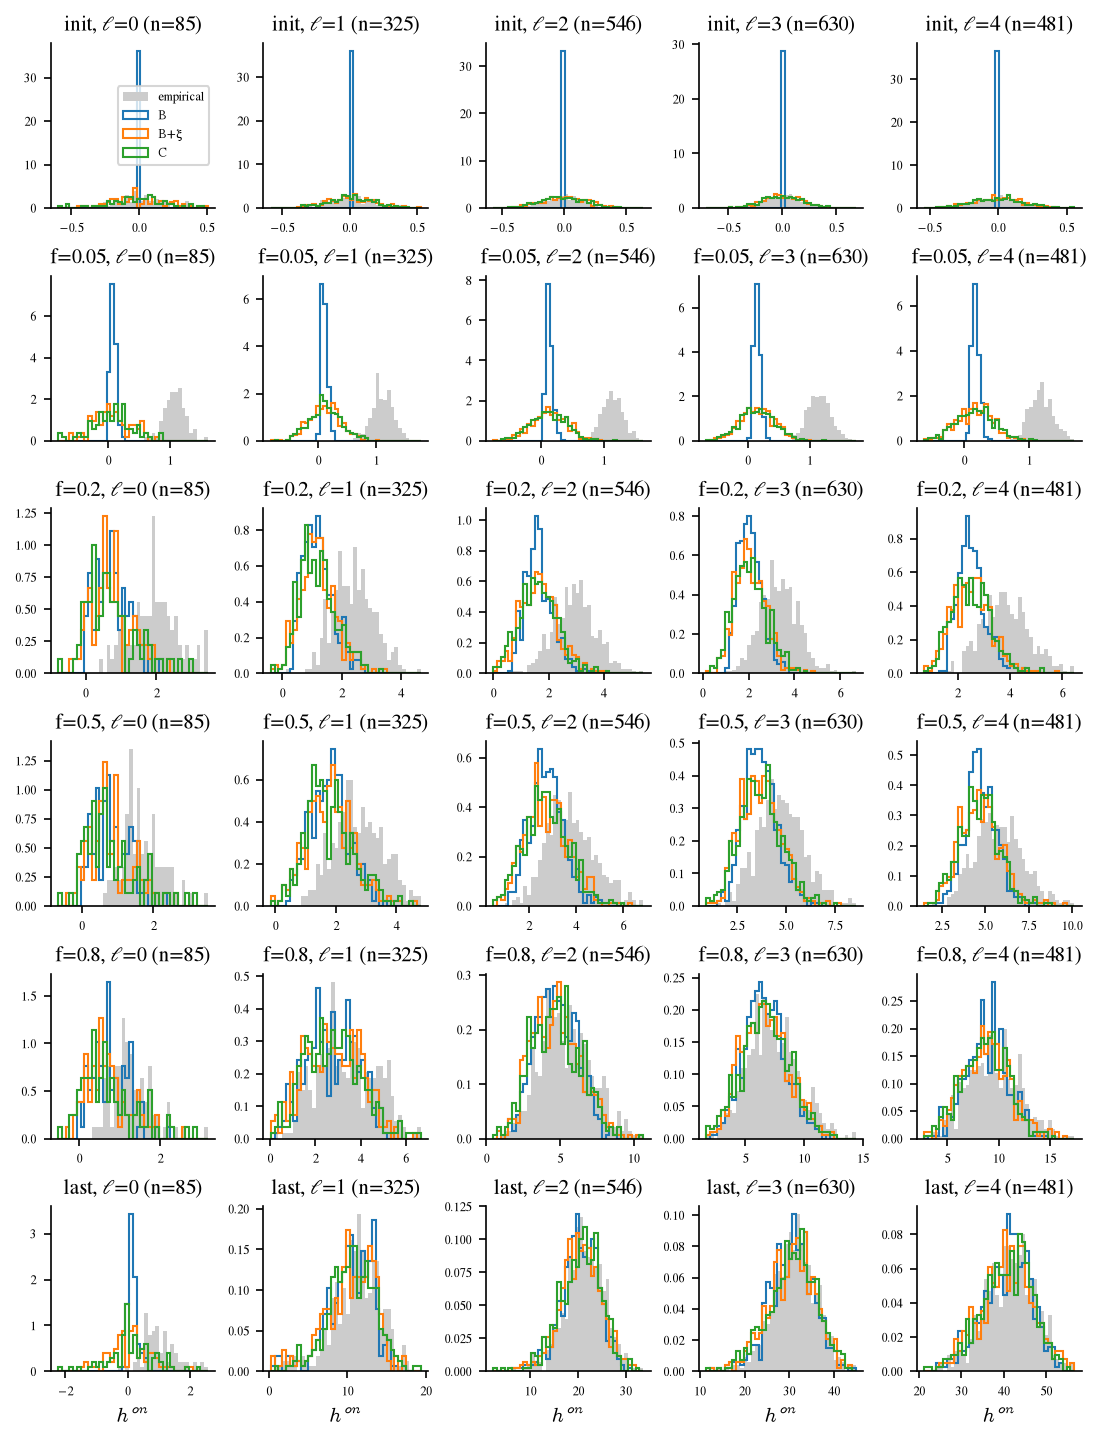

In [8]:
MU, ELLS = L, range(5)
fig, axes = create_fig(len(SNAPSHOTS), len(ELLS), size='double', h=0.22 * len(SNAPSHOTS), sharex=False, sharey=False)
for row, (name, logits) in zip(axes, versions.items()):
    for ax, ell in zip(row, ELLS):
        rows = (logits["mu"] == MU) & (logits["ell"] == ell)
        if rows.sum() < 10:
            ax.set_axis_off()
            continue
        values = {source: logits[source][rows, -1].numpy() for source in SOURCES}
        bins = np.histogram_bin_edges(np.concatenate(list(values.values())), bins=40)
        for source, color in SOURCES.items():
            if source == "empirical":
                ax.hist(values[source], bins=bins, density=True, color="0.8", label=source)
            else:
                ax.hist(values[source], bins=bins, density=True, histtype="step", color=color, label=source)
        ax.set_title(f"{name}, ℓ={ell} (n={int(rows.sum())})")
axes[0, 0].legend()
for ax in axes[-1]:
    ax.set_xlabel(r"$h^{on}$")
plt.show()

### 3b. Mean and variance of each entry, per $\ell$: the law of total variance

(C4): $\mathrm{Var}(h|\ell)=\mathrm{Var}(\bar h(\mathfrak S)|\ell)+\mathbb E[\widehat K(\mathfrak S)|\ell]$. The first term is the variance of B over the queries. The second is the mean of the formulas of `noise_variances` on the measured variables. Their sum is the prediction, against the empirical variance. Three entries:
- the target $h^{on}$;
- the trigger mean $\frac1K\sum_\tau h_\tau$, whose noise variance is $V^\mathcal T_c+V^\mathcal T_i/K$;
- the non-targets pooled over $b$ and rows, with noise variance $V^{off}_b$.

Top row: means. Bottom row: variances (empirical, B+ξ, C, and B + formula).

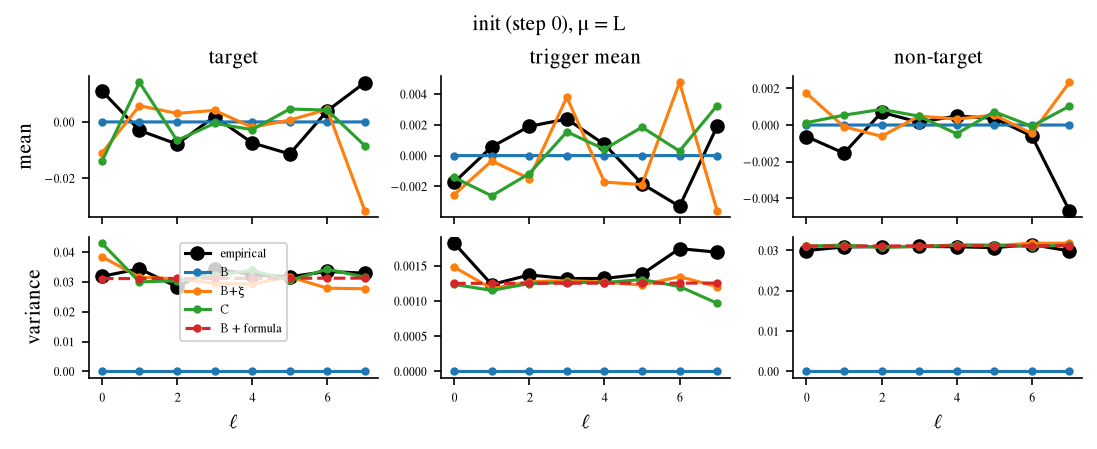

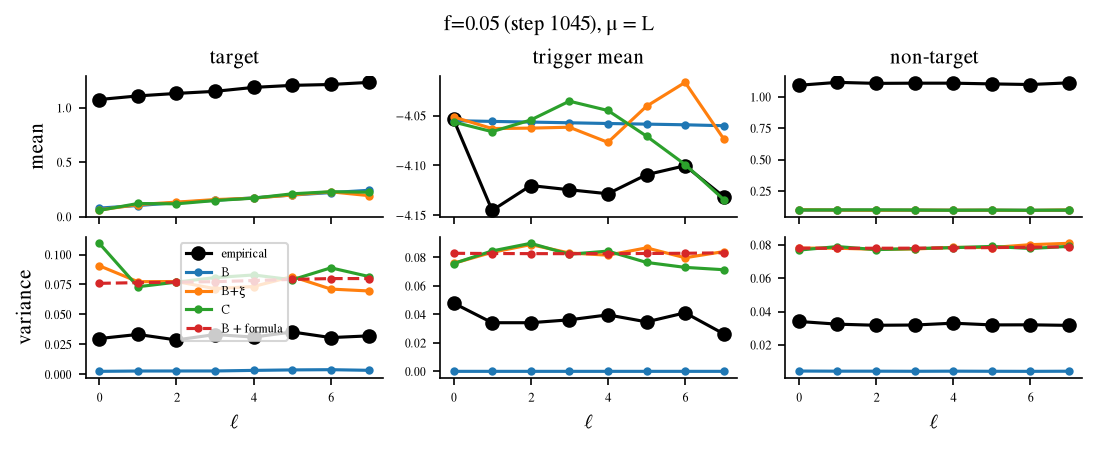

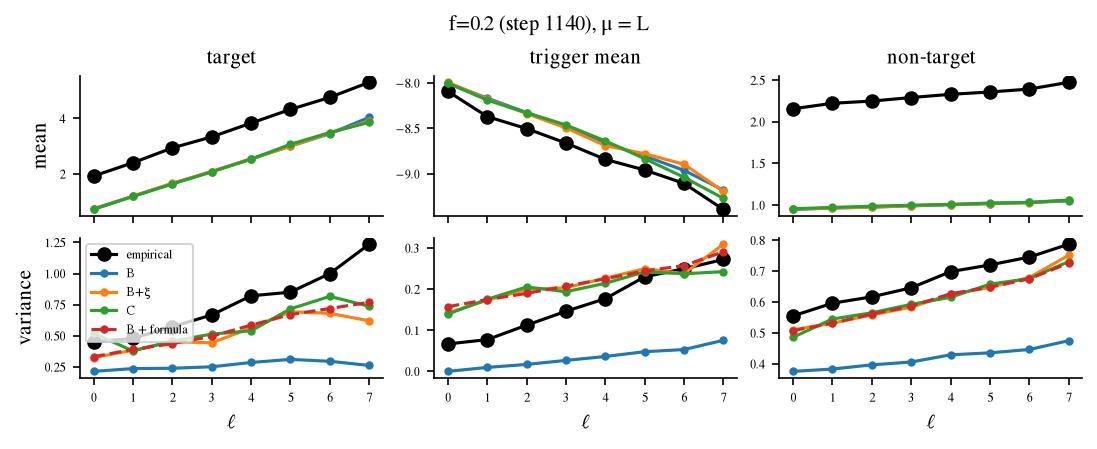

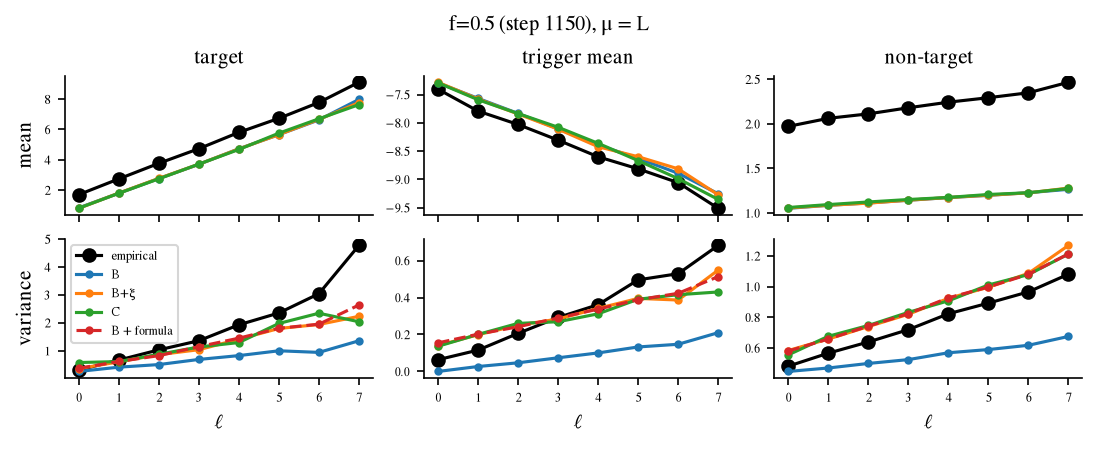

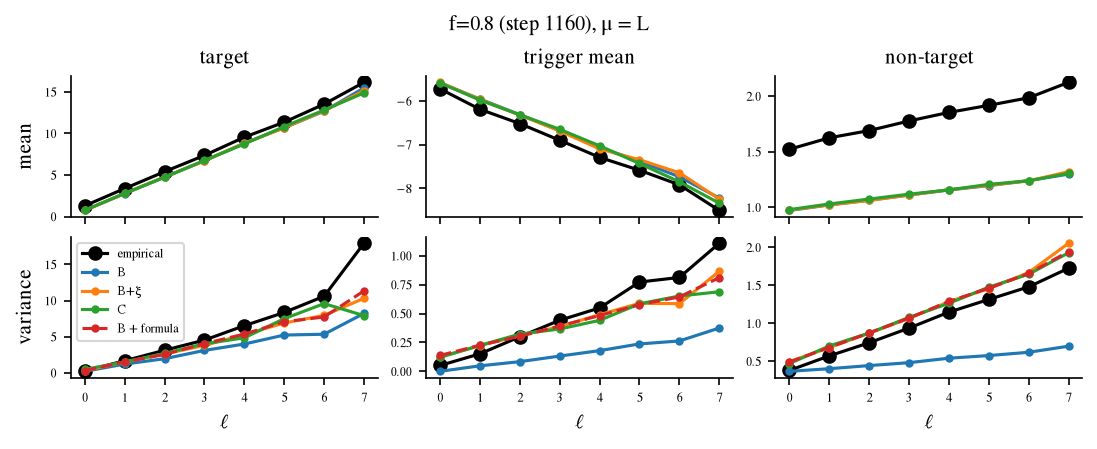

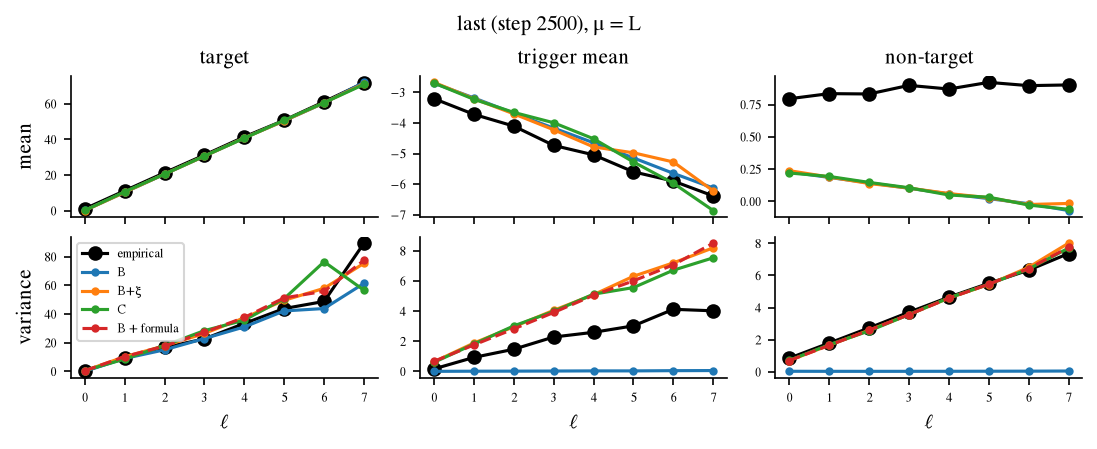

In [9]:
def entry_stats(logits, mu, ells):
    # per ell: mean and variance of the three entries for every source, and the formula prediction
    out = []
    for ell in ells:
        rows = (logits["mu"] == mu) & (logits["ell"] == ell)
        if rows.sum() < 10:
            continue
        noise = {name: value[rows] for name, value in logits["noise"].items()}
        for source in SOURCES:
            h = logits[source][rows]
            entries = {"target": h[:, -1], "trigger mean": h[:, :K].mean(1), "non-target": h[:, K:-1].reshape(-1)}
            for entry, value in entries.items():
                out.append({"ell": ell, "source": source, "entry": entry, "mean": value.mean().item(),
                            "var": value.var().item()})
        B = logits["B"][rows]
        formula = {"target": B[:, -1].var() + noise["target"].mean(),
                   "trigger mean": B[:, :K].mean(1).var() + noise["trigger_common"].mean()
                                   + noise["trigger_individual"].mean() / K,
                   "non-target": B[:, K:-1].reshape(-1).var() + noise["non_target"].mean()}
        for entry, value in formula.items():
            out.append({"ell": ell, "source": "B + formula", "entry": entry, "mean": np.nan, "var": value.item()})
    return pd.DataFrame(out)


STYLE = {**SOURCES, "B + formula": "C3"}
for name, logits in versions.items():
    stats = entry_stats(logits, L, range(8))
    fig, axes = create_fig(2, 3, size='double', h=0.4, sharex=True, sharey=False)
    for column, entry in enumerate(("target", "trigger mean", "non-target")):
        for source, color in STYLE.items():
            part = stats[(stats.entry == entry) & (stats.source == source)]
            marker = "o" if source == "empirical" else "."
            if source != "B + formula":
                axes[0, column].plot(part.ell, part["mean"], marker=marker, color=color, label=source)
            axes[1, column].plot(part.ell, part["var"], marker=marker, color=color,
                                 ls="--" if source == "B + formula" else "-", label=source)
        axes[0, column].set_title(entry)
        axes[1, column].set_xlabel(r"$\ell$")
    axes[0, 0].set_ylabel("mean")
    axes[1, 0].set_ylabel("variance")
    axes[1, 0].legend()
    fig.suptitle(f"{name} (step {SNAPSHOTS[name]}), μ = L")
    plt.show()

### 3c. Trigger and non-target logits

At $\mu=L$, all $\ell$: the trigger entries (individual) and the non-target entries, pooled.

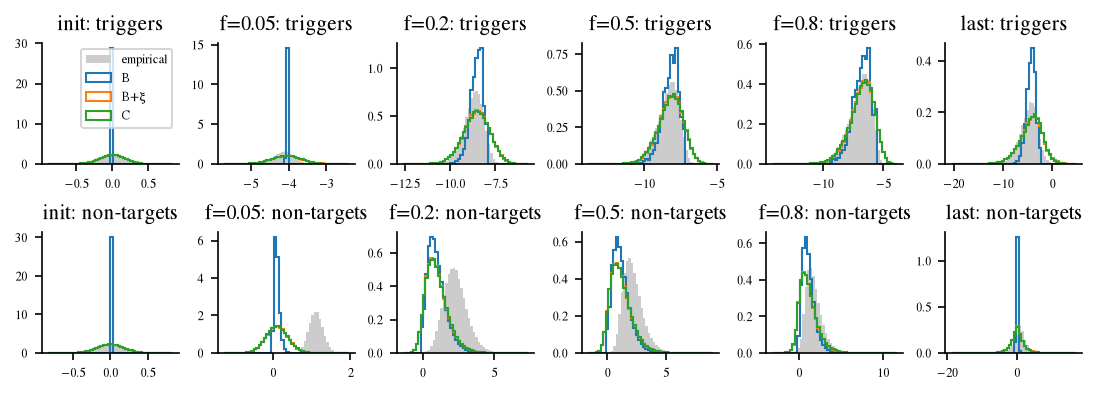

In [10]:
fig, axes = create_fig(2, len(SNAPSHOTS), size='double', h=0.35, sharex=False, sharey=False)
for column, (name, logits) in enumerate(versions.items()):
    rows = logits["mu"] == L
    for row, (entry, block) in enumerate((("triggers", slice(0, K)), ("non-targets", slice(K, V - 1)))):
        ax = axes[row, column]
        values = {source: logits[source][rows][:, block].reshape(-1).numpy() for source in SOURCES}
        bins = np.histogram_bin_edges(np.concatenate(list(values.values())), bins=50)
        for source, color in SOURCES.items():
            if source == "empirical":
                ax.hist(values[source], bins=bins, density=True, color="0.8", label=source)
            else:
                ax.hist(values[source], bins=bins, density=True, histtype="step", color=color, label=source)
        ax.set_title(f"{name}: {entry}")
axes[0, 0].legend()
plt.show()

## 4. The effective loss along training, per simplification level

At every saved step: the order parameters measured from the matrices, then `EffectiveLoss` at each level of `LEVELS`:
- S0: profile, six means, eight variances;
- S1: one pooled variance per matrix;
- S2: no profile;
- S3: no spread (the extended ansatz);
- S4: signal + noise floor;
- S5: signal only.

Both methods are run:
- `"mc"`: sampled variables plus one Gaussian noise draw per row, level (1) of §5.1;
- `"mean"`: mean logits plus the Gaussian closure of the noise. It has no process variance, and $Z_{\rm off}$ is $\sum_b e^{\mathbb E h_b+\mathbb E V_b/2}$; see the code map.

The network's loss is measured on one fixed batch (`LossMetric`: all positions, trigger, non-trigger, trigger with $\ell=0$ and $\ell\ge1$). The effective loss averages over $\mu\in\{8,16,\dots,L\}$, which is enough for the mean over positions. The result is cached next to the run.

In [11]:
MUS_LOSS, NUM_SAMPLES, LOSS_SEQUENCES = range(8, L + 1, 8), 128, 8192
CACHE = Path(BASE, EXPERIMENT, RUN_ID, "effective_levels.pkl")
PARTS = ["loss", "loss_trigg", "loss_non_trigg", "loss_trigg_ell0", "loss_trigg_ell_ge1"]

if CACHE.exists():
    levels = pd.read_pickle(CACHE)
else:
    effective = {method: EffectiveLoss(V, L, K, beta, method=method, mus=MUS_LOSS, num_samples=NUM_SAMPLES,
                                       device=DEVICE) for method in ("mc", "mean")}
    evaluator = Evaluator(scalars=[LossMetric(), LossMetric(positions="trigg"), LossMetric(positions="non_trigg"),
                                   LossMetric(positions="trigg", ell=0), LossMetric(positions="trigg", ell=">=1")],
                          chunk=1024)
    loss_batch, _ = preprocess_batch(run.batch(LOSS_SEQUENCES, seed=BATCH_SEED + 1, device=DEVICE), DEVICE)
    rows = []
    for step in artifact_steps:
        measured = evaluator.scalars(run.model(step, device=DEVICE), loss_batch, step=step)
        rows.append({"step": step, "source": "network", **{part: measured[part] for part in PARTS}})
        order_params = run.order_params(step, profile=True, variances=True)
        for method, loss in effective.items():
            for level in LEVELS:
                parts = loss.breakdown(at_level(order_params, level))
                rows.append({"step": step, "source": f"{method} {level}", "loss": parts["loss"],
                             "loss_trigg": parts["loss_trigg"], "loss_non_trigg": parts["loss_non_trigg"],
                             "loss_trigg_ell0": trigger_loss(parts["clusters"], ell=0),
                             "loss_trigg_ell_ge1": trigger_loss(parts["clusters"], ell=">=1")})
    levels = pd.DataFrame(rows)
    levels.to_pickle(CACHE)
levels.head()

,step,source,loss,loss_trigg,loss_non_trigg,loss_trigg_ell0,loss_trigg_ell_ge1
0,0,network,4.857087,4.857166,4.857071,4.853940,4.858476
1,0,mc S0,4.857219,4.856906,4.857280,4.853569,4.858208
2,0,mc S1,4.857219,4.856886,4.857284,4.853564,4.858183
3,0,mc S2,4.857185,4.856852,4.857249,4.853547,4.858143
4,0,mc S3,4.852030,4.852030,4.852030,4.852030,4.852030


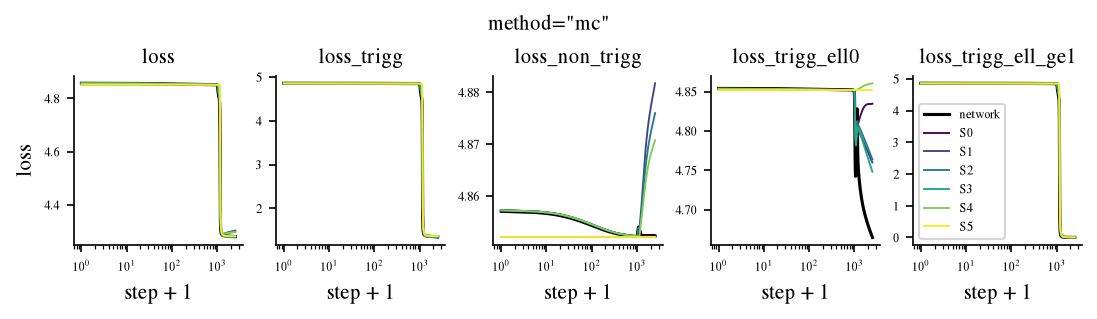

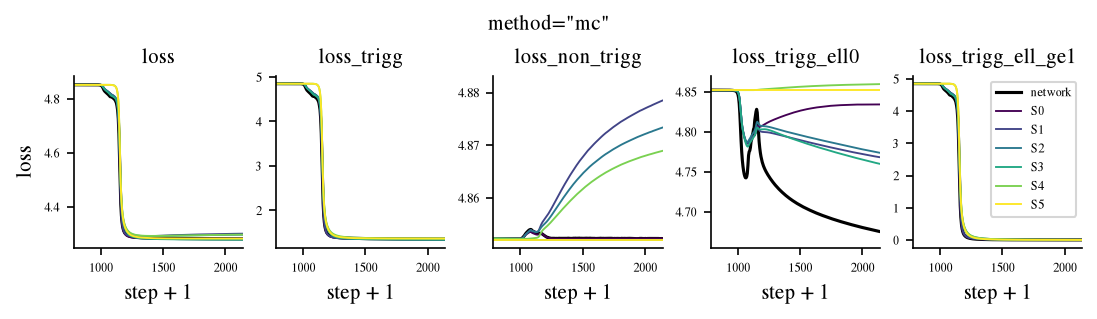

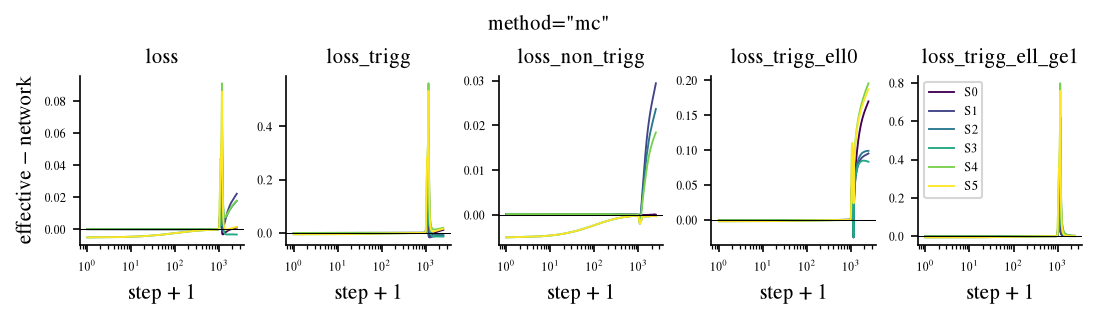

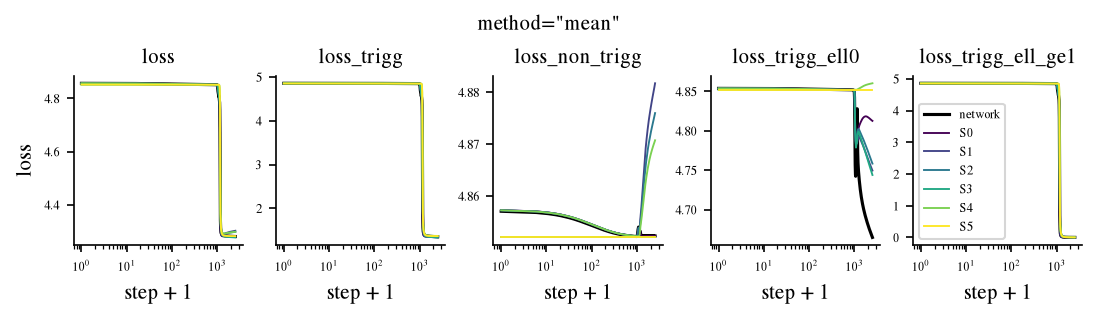

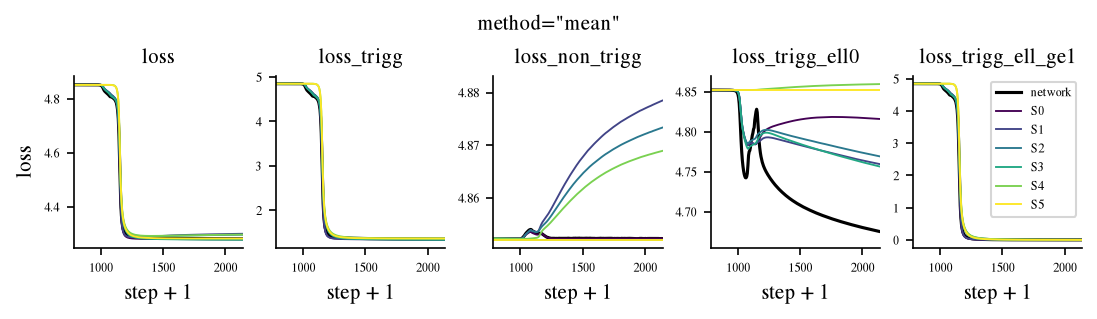

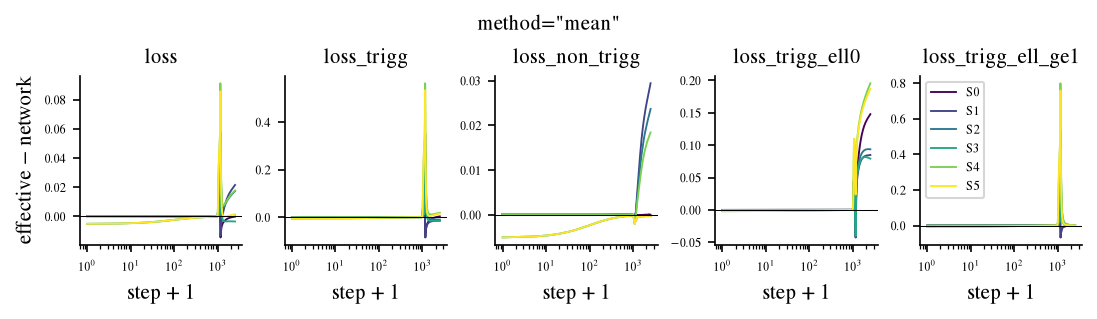

In [12]:
LEVEL_COLORS = {level: plt.cm.viridis(i / (len(LEVELS) - 1)) for i, level in enumerate(LEVELS)}


def plot_levels(method, difference=False, zoom=False):
    # zoom: linear steps over the transition window instead of log steps over the whole run
    fig, axes = create_fig(1, len(PARTS), size='double', h=0.28, sharex=True, sharey=False)
    network = levels[levels.source == "network"].set_index("step")
    for ax, part in zip(axes, PARTS):
        if not difference:
            ax.plot(network.index + 1, network[part], color="k", lw=1.5, label="network")
        for level, color in LEVEL_COLORS.items():
            curve = levels[levels.source == f"{method} {level}"].set_index("step")[part]
            ax.plot(curve.index + 1, curve - network[part] if difference else curve, color=color, lw=0.9, label=level)
        if difference:
            ax.axhline(0, color="k", lw=0.5)
        if zoom:
            ax.set(title=part, xlim=TRANSITION, xlabel="step + 1")
        else:
            ax.set(title=part, xscale="log", xlabel="step + 1")
    axes[0].set_ylabel("effective − network" if difference else "loss")
    axes[-1].legend()
    fig.suptitle(f'method="{method}"')
    plt.show()


for method in ("mc", "mean"):
    plot_levels(method)
    plot_levels(method, zoom=True)
    plot_levels(method, difference=True)

### 4b. Per cluster, at the snapshots

$\mathrm{CE}(\mu=L,\ell)$ of the network (on the batch of §3) against each level, `"mc"`. The quenched scatter of one network is of order 0.1 nats per cluster.

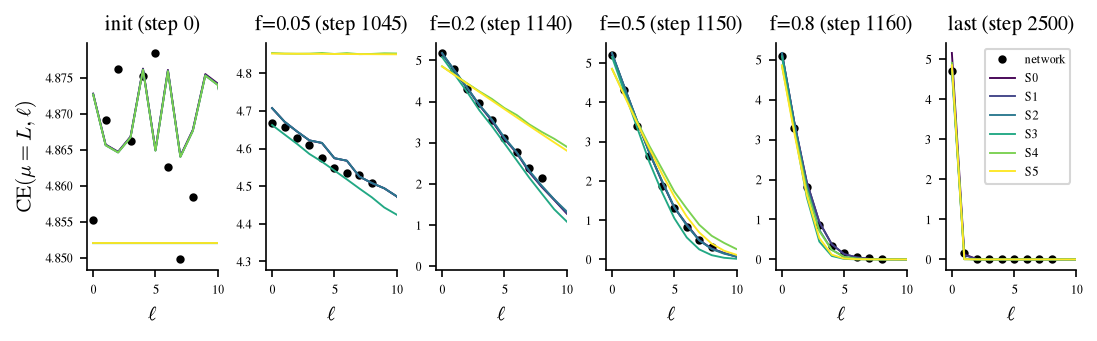

In [13]:
effective_mc = EffectiveLoss(V, L, K, beta, method="mc", mus=[L], num_samples=1024, device=DEVICE)
fig, axes = create_fig(1, len(SNAPSHOTS), size='double', h=0.3, sharex=True, sharey=False)
for ax, (name, step) in zip(axes, SNAPSHOTS.items()):
    logits = versions[name]
    rows = logits["mu"] == L
    clusters = cluster_cross_entropy({"logits": logits["empirical"][rows], "mu": logits["mu"][rows],
                                      "ell": logits["ell"][rows]})
    enough = clusters["count"] >= 20
    ax.plot(clusters["ell"][enough], clusters["cross_entropy"][enough], "ko", ms=3, label="network")
    order_params = run.order_params(step, profile=True, variances=True)
    for level, color in LEVEL_COLORS.items():
        table = effective_mc.breakdown(at_level(order_params, level))["clusters"]
        ax.plot(table["ell"], table["cross_entropy"], color=color, lw=0.9, label=level)
    ax.set(title=f"{name} (step {step})", xlabel=r"$\ell$", xlim=(-0.5, 10))
axes[0].set_ylabel(r"CE$(\mu=L,\ell)$")
axes[-1].legend()
plt.show()